In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
!pip install gdown

In [ ]:
import gdown

file_id = '1OOlNjO_zgh-mG97RyQtgDrWotz3XSOGU'

gdown.download(
    f'https://drive.google.com/uc?id={file_id}',
    'heart_2022_with_nans.csv',
    quiet=False
)

df = pd.read_csv('heart_2022_with_nans.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1OOlNjO_zgh-mG97RyQtgDrWotz3XSOGU
From (redirected): https://drive.google.com/uc?id=1OOlNjO_zgh-mG97RyQtgDrWotz3XSOGU&confirm=t&uuid=25dd20b9-14c7-41b1-a4f4-709f2c4d34be
To: /content/heart_2022_with_nans.csv
100%|██████████| 140M/140M [00:01<00:00, 70.8MB/s]


In [ ]:
import pandas as pd
non_penyakit = [
    "State",
    "Sex",
    "LastCheckupTime",
    "PhysicalActivities",
    "SleepHours",
    "RemovedTeeth",
    "SmokerStatus",
    "ECigaretteUsage",
    "ChestScan",
    "RaceEthnicityCategory",
    "AgeCategory",
    "HeightInMeters",
    "WeightInKilograms",
    "BMI",
    "AlcoholDrinkers",
    "HIVTesting",
    "FluVaxLast12",
    "PneumoVaxEver",
    "TetanusLast10Tdap",
    "HighRiskLastYear",
    "PhysicalHealthDays",
    "MentalHealthDays",
    "DifficultyWalking",
    "GeneralHealth"
]

df = df[non_penyakit]
df.head()

,State,Sex,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,...,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,PhysicalHealthDays,MentalHealthDays,DifficultyWalking,GeneralHealth
0,Alabama,Female,Within past year (anytime less than 12 months ...,No,8.0,NaN,Never smoked,Not at all (right now),No,"White only, Non-Hispanic",...,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,0.0,0.0,No,Very good
1,Alabama,Female,NaN,No,6.0,NaN,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",...,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,0.0,0.0,No,Excellent
2,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",...,No,No,No,No,NaN,No,2.0,3.0,No,Very good
3,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,Current smoker - now smokes some days,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",...,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,0.0,0.0,No,Excellent
4,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",...,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,2.0,0.0,No,Fair


In [ ]:
print(df.columns)

Index(['State', 'Sex', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours',
       'RemovedTeeth', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan',
       'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters',
       'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting',
       'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap',
       'HighRiskLastYear', 'PhysicalHealthDays', 'MentalHealthDays',
       'DifficultyWalking', 'GeneralHealth'],
      dtype='object')


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   State                  445132 non-null  object 
 1   Sex                    445132 non-null  object 
 2   LastCheckupTime        436824 non-null  object 
 3   PhysicalActivities     444039 non-null  object 
 4   SleepHours             439679 non-null  float64
 5   RemovedTeeth           433772 non-null  object 
 6   SmokerStatus           409670 non-null  object 
 7   ECigaretteUsage        409472 non-null  object 
 8   ChestScan              389086 non-null  object 
 9   RaceEthnicityCategory  431075 non-null  object 
 10  AgeCategory            436053 non-null  object 
 11  HeightInMeters         416480 non-null  float64
 12  WeightInKilograms      403054 non-null  float64
 13  BMI                    396326 non-null  float64
 14  AlcoholDrinkers        398558 non-nu

In [ ]:
df.describe()

,SleepHours,HeightInMeters,WeightInKilograms,BMI,PhysicalHealthDays,MentalHealthDays
count,439679.000000,416480.000000,403054.000000,396326.000000,434205.000000,436065.000000
mean,7.022983,1.702691,83.074470,28.529842,4.347919,4.382649
std,1.502425,0.107177,21.448173,6.554889,8.688912,8.387475
min,1.000000,0.910000,22.680000,12.020000,0.000000,0.000000
25%,6.000000,1.630000,68.040000,24.130000,0.000000,0.000000
50%,7.000000,1.700000,80.740000,27.440000,0.000000,0.000000
75%,8.000000,1.780000,95.250000,31.750000,3.000000,5.000000
max,24.000000,2.410000,292.570000,99.640000,30.000000,30.000000


In [ ]:
target_col = 'GeneralHealth'
feature_cols = [c for c in df.columns if c != target_col]

numeric_feature_cols = df[feature_cols].select_dtypes(include=np.number).columns

summary = df[numeric_feature_cols].agg(['mean','std','min','max']).T
summary['skewness'] = df[numeric_feature_cols].skew()
summary = summary.round(3)
print(summary.to_string())

                      mean     std    min     max  skewness
SleepHours           7.023   1.502   1.00   24.00     0.765
HeightInMeters       1.703   0.107   0.91    2.41     0.029
WeightInKilograms   83.074  21.448  22.68  292.57     1.076
BMI                 28.530   6.555  12.02   99.64     1.388
PhysicalHealthDays   4.348   8.689   0.00   30.00     2.180
MentalHealthDays     4.383   8.387   0.00   30.00     2.123


Missvalue dan sparsity

In [ ]:
# Missing value
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Percent": missing_percent
})

missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Percent
TetanusLast10Tdap,82516,18.537423
PneumoVaxEver,77040,17.307226
HIVTesting,66127,14.855593
ChestScan,56046,12.590872
HighRiskLastYear,50623,11.372582
BMI,48806,10.964388
FluVaxLast12,47121,10.585849
AlcoholDrinkers,46574,10.462964
WeightInKilograms,42078,9.452926
ECigaretteUsage,35660,8.011107


In [ ]:
sparsity = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"Persentase sparsity data: {sparsity:.2f}%")

Persentase sparsity data: 6.66%


Duplikat

In [ ]:
df.duplicated().sum()

np.int64(356)

Outlier

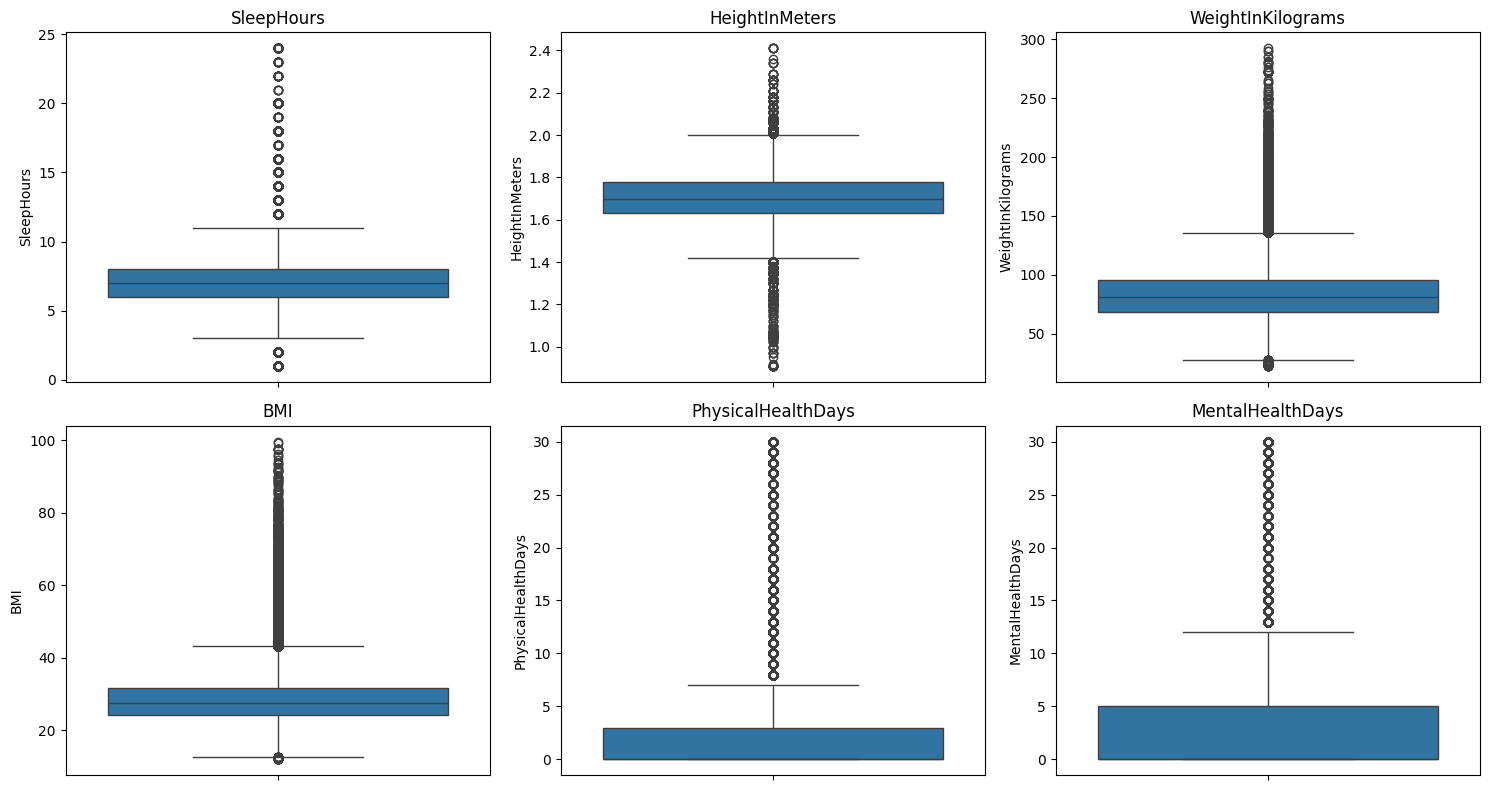

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,8))
for i, col in enumerate(num_cols[:6]):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Cek Imbalance

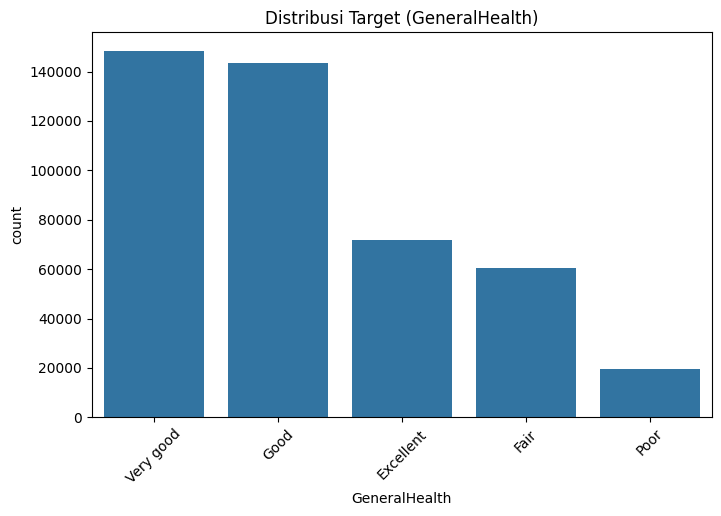

,proportion
GeneralHealth,
Very good,33.438304
Good,32.346700
Excellent,16.191146
Fair,13.577018
Poor,4.446832


In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='GeneralHealth', order=df['GeneralHealth'].value_counts().index)
plt.title("Distribusi Target (GeneralHealth)")
plt.xticks(rotation=45)
plt.show()


df['GeneralHealth'].value_counts(normalize=True) * 100

Distribusi

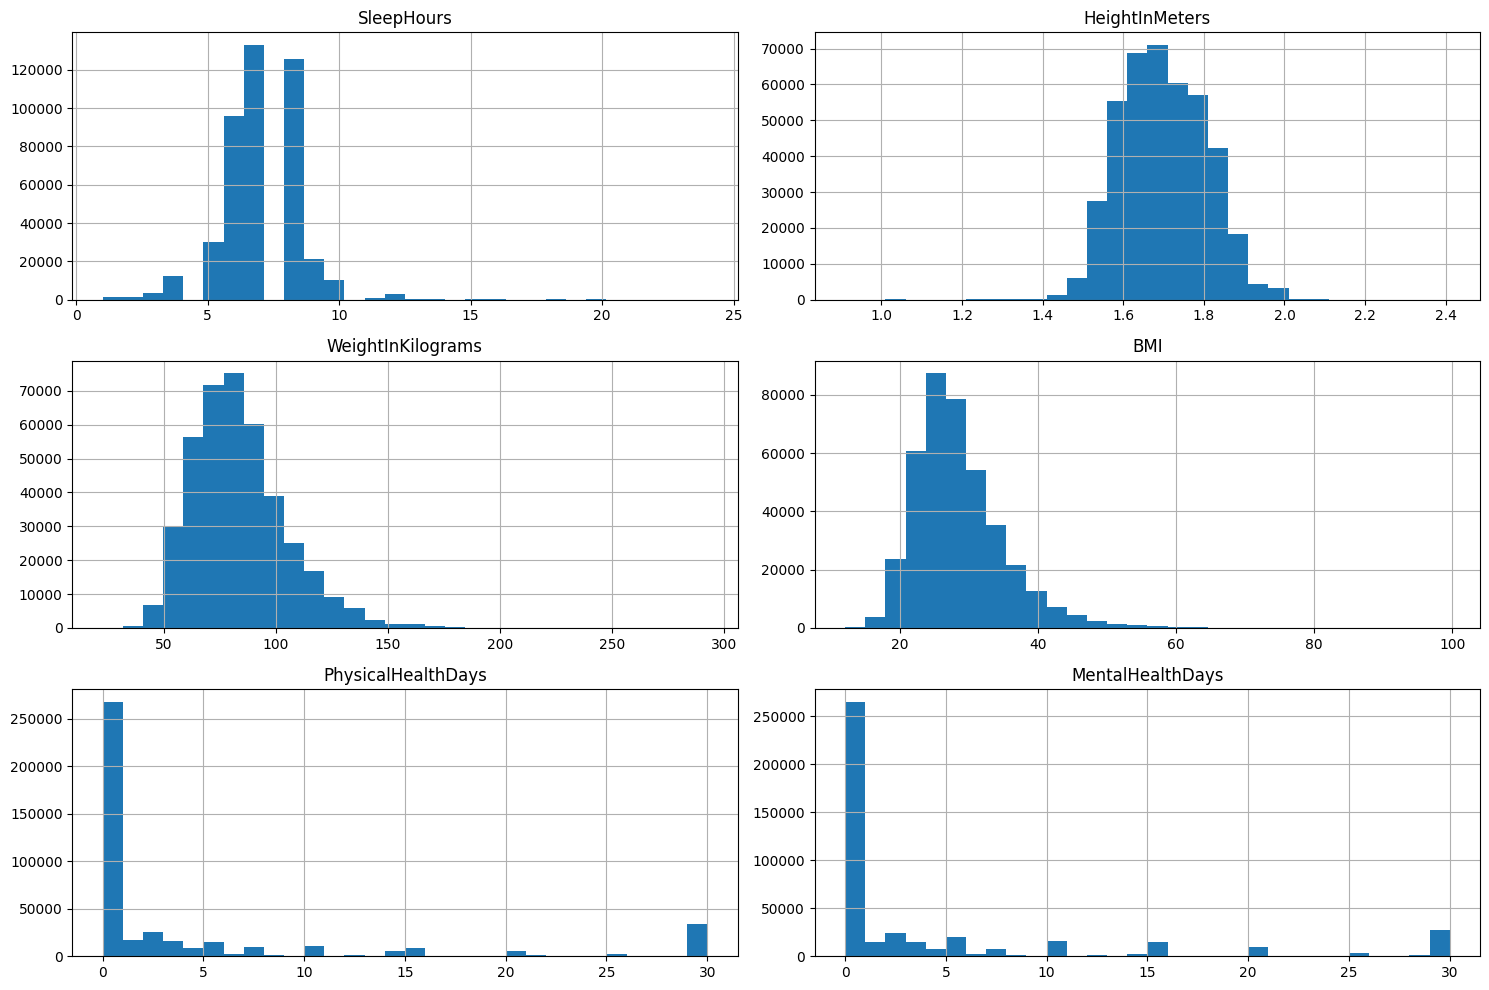

In [ ]:
df.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

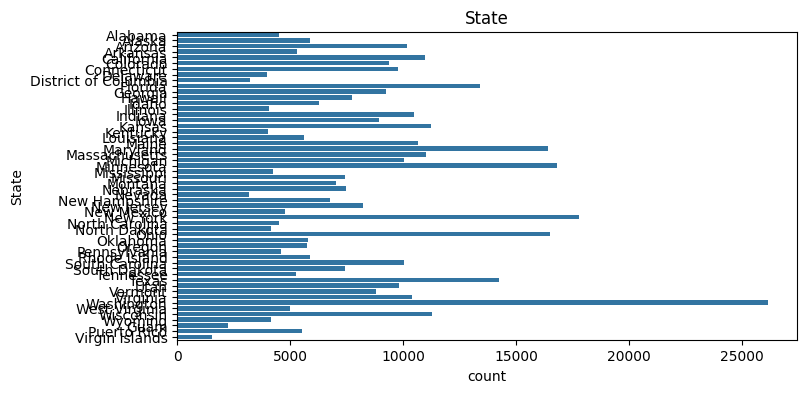

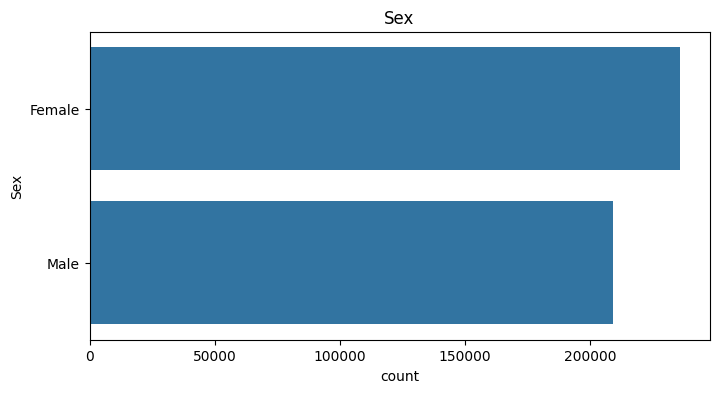

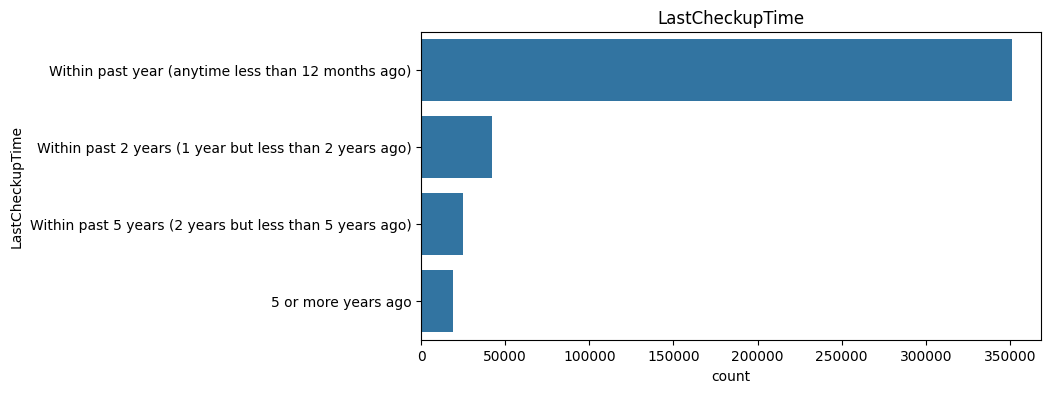

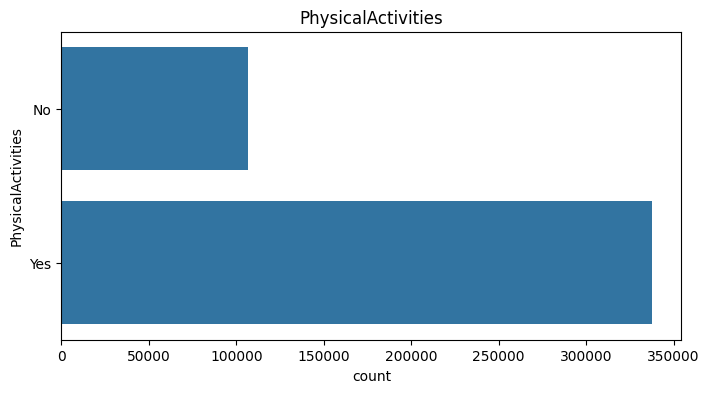

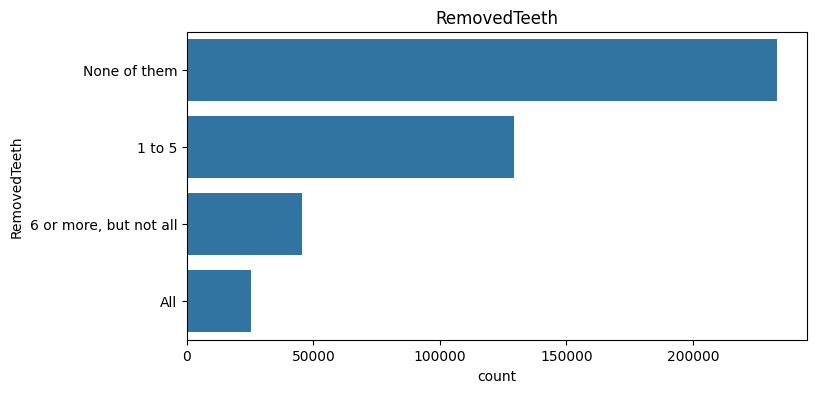

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols[:5]:
    plt.figure(figsize=(8,4))
    sns.countplot(y=df[col])
    plt.title(col)
    plt.show()

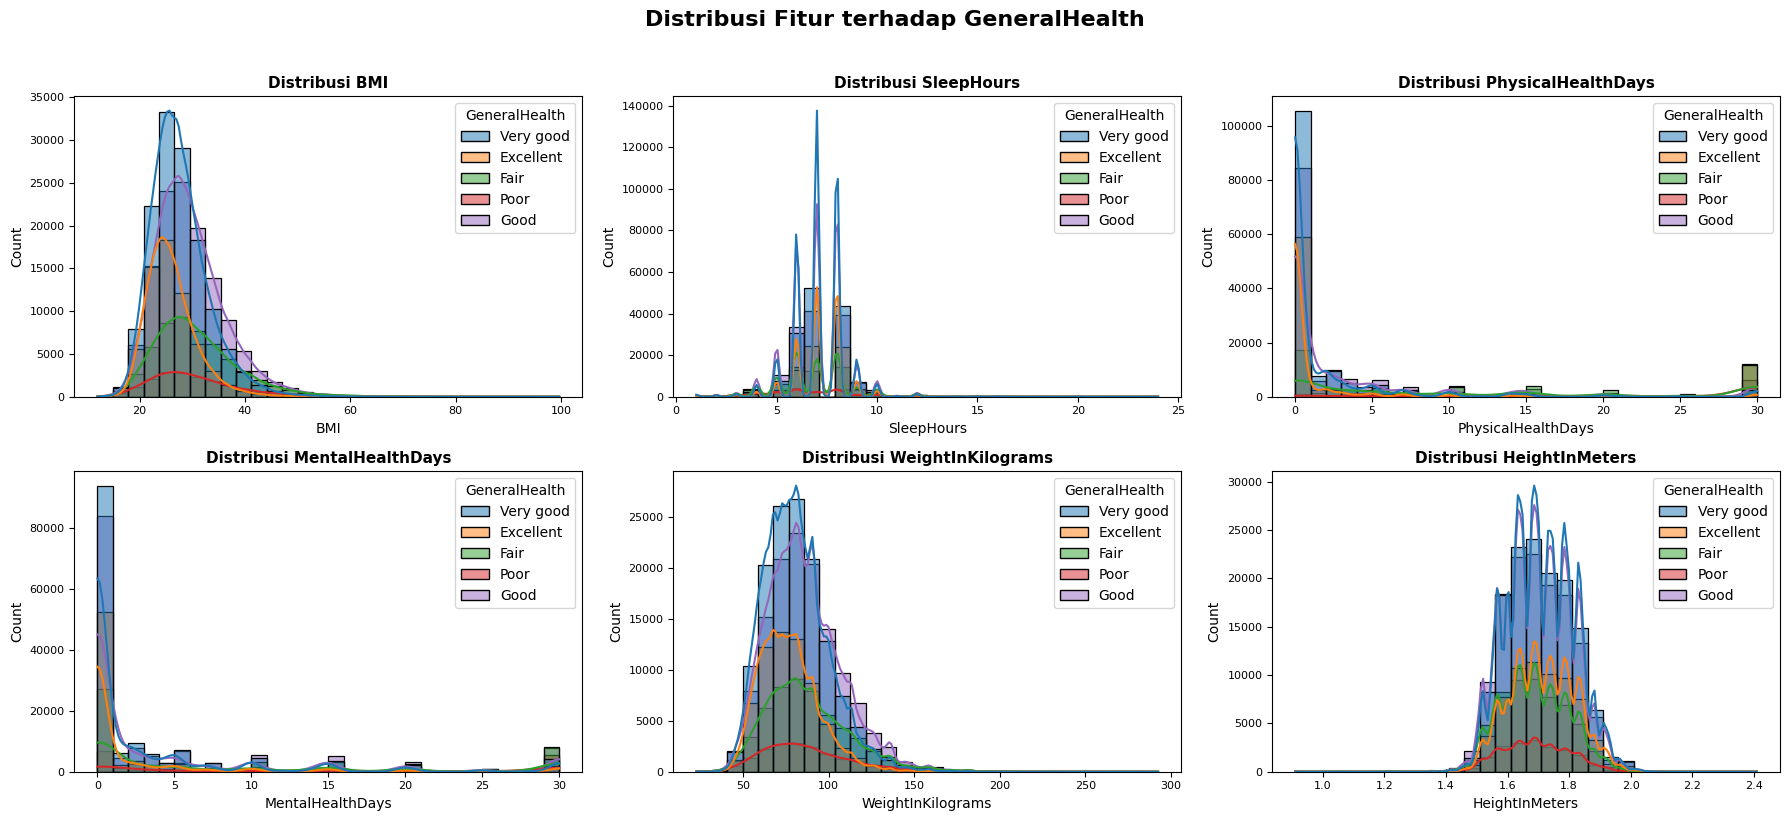

In [ ]:
# Distribusi fitur berdasarkan GeneralHealth

import matplotlib.pyplot as plt
import seaborn as sns

# target
target_col = 'GeneralHealth'

# fitur numerik
feature_cols = [
    'BMI',
    'SleepHours',
    'PhysicalHealthDays',
    'MentalHealthDays',
    'WeightInKilograms',
    'HeightInMeters'
]

# jumlah kolom subplot
n_cols = 3
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(18, n_rows * 4))

axes = axes.flatten()

# looping visualisasi
for i, col in enumerate(feature_cols):

    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        bins=30,
        kde=True,
        alpha=0.5,
        ax=axes[i]
    )

    axes[i].set_title(
        f'Distribusi {col}',
        fontsize=11,
        fontweight='bold'
    )

    axes[i].tick_params(labelsize=8)

# hapus subplot kosong
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# judul utama
plt.suptitle(
    'Distribusi Fitur terhadap GeneralHealth',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

Korelasi

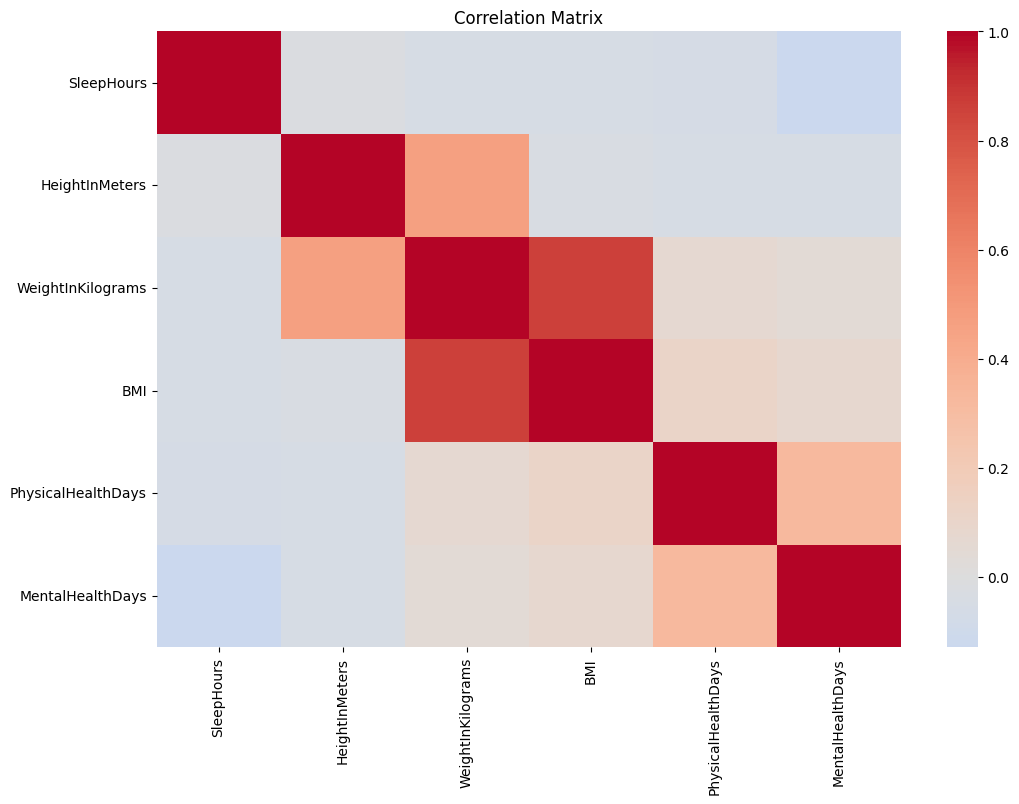

In [ ]:
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

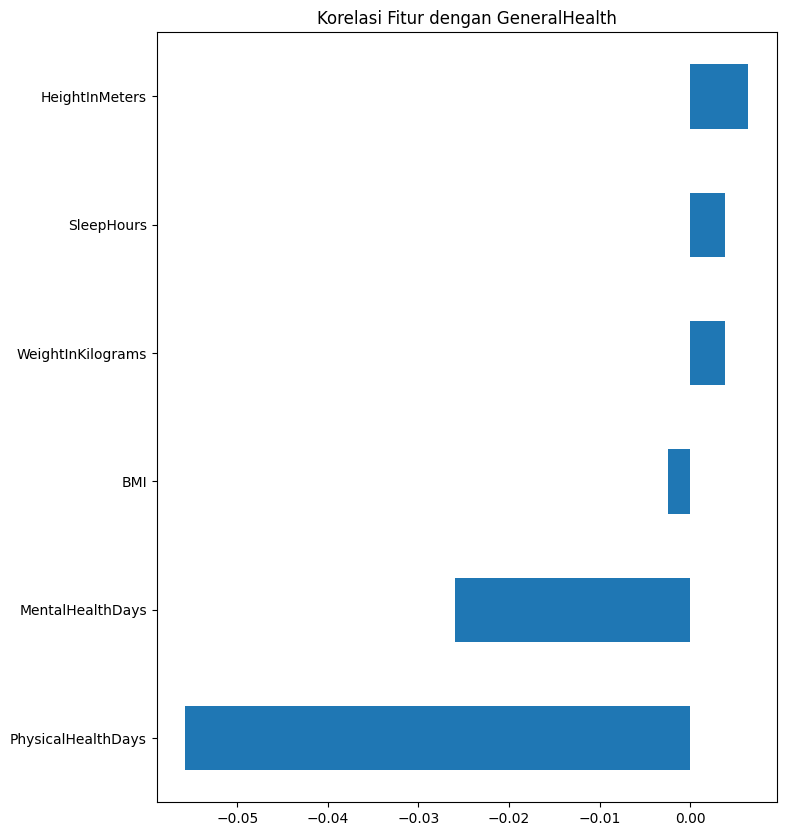

In [ ]:
df_encoded = df.copy()

le = LabelEncoder()
df_encoded['GeneralHealth_enc'] = le.fit_transform(df_encoded['GeneralHealth'])

corr_target = df_encoded[num_cols].corrwith(df_encoded['GeneralHealth_enc']).sort_values()

plt.figure(figsize=(8,10))
corr_target.plot(kind='barh')
plt.title("Korelasi Fitur dengan GeneralHealth")
plt.show()

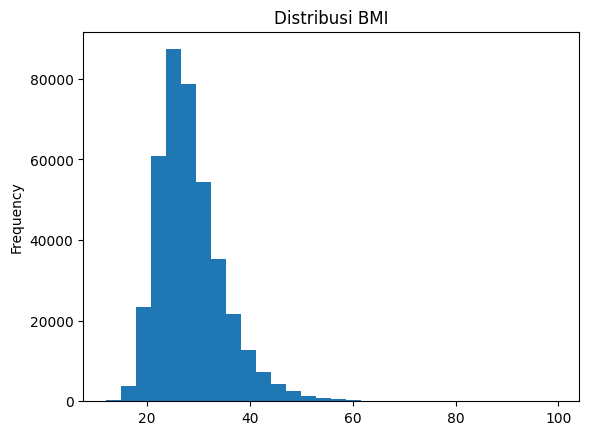

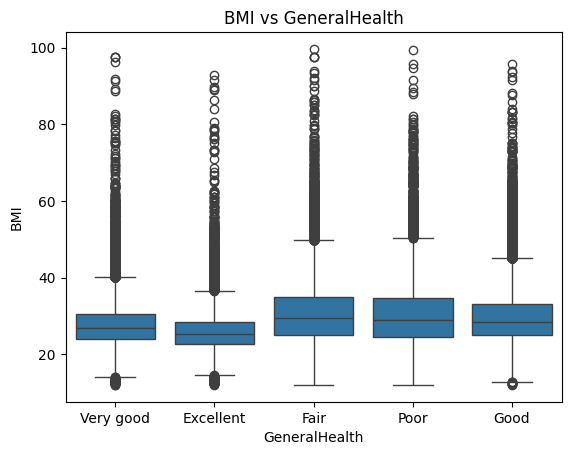

In [ ]:
df['BMI'].plot(kind='hist', bins=30, title="Distribusi BMI")
plt.show()

sns.boxplot(x='GeneralHealth', y='BMI', data=df)
plt.title("BMI vs GeneralHealth")
plt.show()

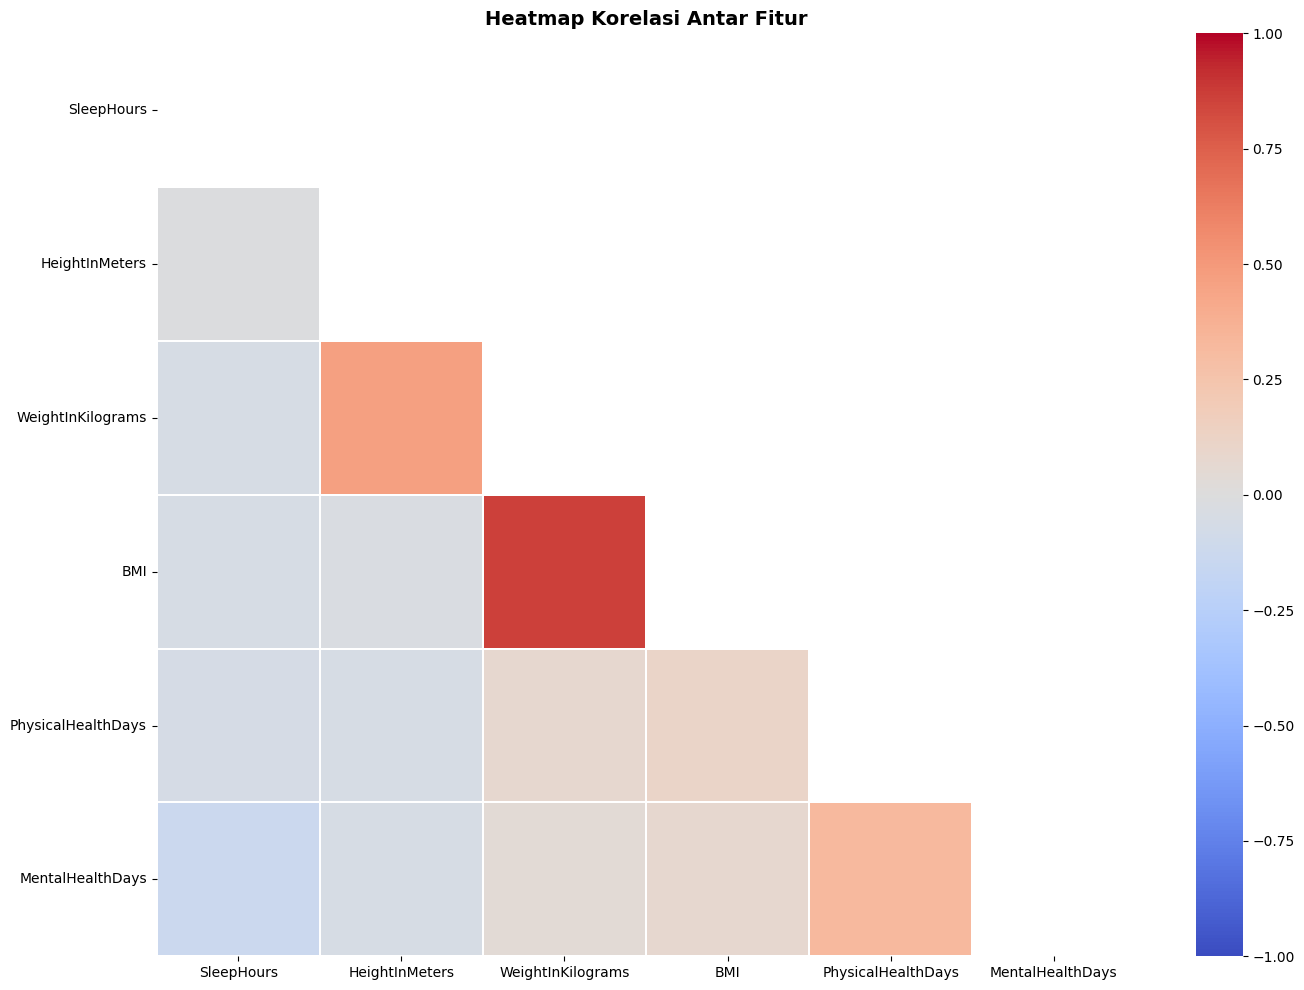

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


feature_cols = df.select_dtypes(include=np.number).columns


corr_matrix = df[feature_cols].corr()


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# visualisasi
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3
)

plt.title('Heatmap Korelasi Antar Fitur',
          fontsize=14,
          fontweight='bold')

plt.tight_layout()
plt.show()

# Preprocessing

### Drop Missing Value pada Target

In [ ]:
print("Missing target:", df['GeneralHealth'].isnull().sum())

Missing target: 1198


In [ ]:
df = df.dropna(subset=['GeneralHealth'])

In [ ]:
print("Missing target after:", df['GeneralHealth'].isnull().sum())

Missing target after: 0


In [ ]:
print("Shape dataset:", df.shape)

Shape dataset: (443934, 24)


## Handling Duplicate

In [ ]:
print("Duplicate:", df.duplicated().sum())

Duplicate: 351


In [ ]:
df = df.drop_duplicates()

In [ ]:
print("Duplicate after:", df.duplicated().sum())

Duplicate after: 0


In [ ]:
print("Shape dataset:", df.shape)

Shape dataset: (443583, 24)


## Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='GeneralHealth')
y = df['GeneralHealth']

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (354866, 23)
X_test : (88717, 23)
y_train: (354866,)
y_test : (88717,)


## Handle Missing Value

### Numerik

In [ ]:
from sklearn.impute import SimpleImputer
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
num_imputer = SimpleImputer(strategy='median')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])

X_test[num_cols] = num_imputer.transform(X_test[num_cols])

In [ ]:
# Cek missing numerik
print("Missing numerik train:")
print(X_train[num_cols].isnull().sum())

print("\nMissing numerik test:")
print(X_test[num_cols].isnull().sum())

Missing numerik train:
SleepHours            0
HeightInMeters        0
WeightInKilograms     0
BMI                   0
PhysicalHealthDays    0
MentalHealthDays      0
dtype: int64

Missing numerik test:
SleepHours            0
HeightInMeters        0
WeightInKilograms     0
BMI                   0
PhysicalHealthDays    0
MentalHealthDays      0
dtype: int64


### Kategorikal

In [ ]:
cat_cols = X_train.select_dtypes(include=['object']).columns

cat_imputer = SimpleImputer(
    strategy='constant',
    fill_value='Unknown'
)

# Fit train
X_train[cat_cols] = cat_imputer.fit_transform(
    X_train[cat_cols]
)

In [ ]:
X_test[cat_cols] = cat_imputer.transform(
    X_test[cat_cols]
)

# Cek missing kategorikal
print("Missing kategorikal train:")
print(X_train[cat_cols].isnull().sum())

print("\nMissing kategorikal test:")
print(X_test[cat_cols].isnull().sum())

Missing kategorikal train:
State                    0
Sex                      0
LastCheckupTime          0
PhysicalActivities       0
RemovedTeeth             0
SmokerStatus             0
ECigaretteUsage          0
ChestScan                0
RaceEthnicityCategory    0
AgeCategory              0
AlcoholDrinkers          0
HIVTesting               0
FluVaxLast12             0
PneumoVaxEver            0
TetanusLast10Tdap        0
HighRiskLastYear         0
DifficultyWalking        0
dtype: int64

Missing kategorikal test:
State                    0
Sex                      0
LastCheckupTime          0
PhysicalActivities       0
RemovedTeeth             0
SmokerStatus             0
ECigaretteUsage          0
ChestScan                0
RaceEthnicityCategory    0
AgeCategory              0
AlcoholDrinkers          0
HIVTesting               0
FluVaxLast12             0
PneumoVaxEver            0
TetanusLast10Tdap        0
HighRiskLastYear         0
DifficultyWalking        0
dtype: int64


## Feature Engineering

### Encoding

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

binary_cols = [
    'PhysicalActivities', 'ChestScan', 'AlcoholDrinkers',
    'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
    'DifficultyWalking', 'HighRiskLastYear'
]

binary_cols = [c for c in binary_cols if c in X_train.columns]

binary_map = {
    'Yes': 1,
    'No': 0,
    'Unknown': -1
}

for col in binary_cols:
    X_train[col] = X_train[col].map(binary_map)
    X_test[col]  = X_test[col].map(binary_map)

print(X_train[binary_cols].head())
print(X_train[binary_cols].head())

        PhysicalActivities  ChestScan  AlcoholDrinkers  HIVTesting  \
186692                   1          0                1           0   
326706                   0          1                1           0   
102047                   1          0                1           0   
296183                   0          0                0           1   
314150                   1          0                0           0   

        FluVaxLast12  PneumoVaxEver  DifficultyWalking  HighRiskLastYear  
186692             0              0                  0                 0  
326706             1              1                  1                 0  
102047             0              1                  0                 0  
296183             0              0                  0                 0  
314150             1              0                  0                 0  
        PhysicalActivities  ChestScan  AlcoholDrinkers  HIVTesting  \
186692                   1          0                1     

In [ ]:
sex_map = {
    'Female': 0,
    'Male': 1
}

X_train['Sex'] = X_train['Sex'].map(sex_map)
X_test['Sex']  = X_test['Sex'].map(sex_map)

print(X_train['Sex'].head())

186692    1
326706    0
102047    0
296183    0
314150    0
Name: Sex, dtype: int64


In [ ]:
from sklearn.preprocessing import OneHotEncoder

nominal_cols = ['State', 'RaceEthnicityCategory', 'TetanusLast10Tdap']
nominal_cols = [c for c in nominal_cols if c in X_train.columns]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

ohe_train = ohe.fit_transform(X_train[nominal_cols])
ohe_test  = ohe.transform(X_test[nominal_cols])

ohe_cols = ohe.get_feature_names_out(nominal_cols)

ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
ohe_test_df  = pd.DataFrame(ohe_test,  columns=ohe_cols, index=X_test.index)

X_train = X_train.drop(columns=nominal_cols)
X_test  = X_test.drop(columns=nominal_cols)

X_train = pd.concat([X_train, ohe_train_df], axis=1)
X_test  = pd.concat([X_test,  ohe_test_df],  axis=1)

print(ohe_train_df.head())

        State_Alaska  State_Arizona  State_Arkansas  State_California  \
186692           0.0            0.0             0.0               0.0   
326706           0.0            0.0             0.0               0.0   
102047           0.0            0.0             0.0               0.0   
296183           0.0            0.0             0.0               0.0   
314150           0.0            0.0             0.0               0.0   

        State_Colorado  State_Connecticut  State_Delaware  \
186692             0.0                0.0             0.0   
326706             0.0                0.0             0.0   
102047             0.0                0.0             0.0   
296183             0.0                0.0             0.0   
314150             0.0                0.0             0.0   

        State_District of Columbia  State_Florida  State_Georgia  ...  \
186692                         0.0            0.0            0.0  ...   
326706                         0.0            0.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = [
    'SmokerStatus',
    'ECigaretteUsage',
    'LastCheckupTime',
    'RemovedTeeth',
    'AgeCategory'
]

ordinal_cols = [c for c in ordinal_cols if c in X_train.columns]

ord_encoder2 = OrdinalEncoder(
    categories=[
        ['Never smoked', 'Former smoker', 'Current smoker - some days', 'Current smoker - every day'],

        ['Never used e-cigarettes in my entire life', 'Not at all (right now)',
         'Use them some days', 'Use them every day'],

        ['5 or more years ago',
         'Within past 5 years (2 years but less than 5 years ago)',
         'Within past 2 years (1 year but less than 2 years ago)',
         'Within past year (anytime less than 12 months ago)'],

        ['None of them', '1 to 5', '6 or more, but not all', 'All'],

        ['Age 18 to 24', 'Age 25 to 29', 'Age 30 to 34',
         'Age 35 to 39', 'Age 40 to 44', 'Age 45 to 49',
         'Age 50 to 54', 'Age 55 to 59', 'Age 60 to 64',
         'Age 65 to 69', 'Age 70 to 74', 'Age 75 to 79',
         'Age 80 or older']
    ],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[ordinal_cols] = ord_encoder2.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols]  = ord_encoder2.transform(X_test[ordinal_cols])

print(X_train[ordinal_cols].head())

        SmokerStatus  ECigaretteUsage  LastCheckupTime  RemovedTeeth  \
186692           0.0              0.0              3.0           0.0   
326706           1.0              0.0              3.0           1.0   
102047           0.0              0.0              3.0           0.0   
296183           0.0              0.0              3.0           0.0   
314150           0.0              0.0              3.0           0.0   

        AgeCategory  
186692          1.0  
326706          9.0  
102047          9.0  
296183          2.0  
314150          3.0  


In [ ]:
# Encoding target
target_order = [['Poor', 'Fair', 'Good', 'Very good', 'Excellent']]

target_encoder = OrdinalEncoder(categories=target_order)

y_train = target_encoder.fit_transform(y_train.values.reshape(-1, 1)).ravel().astype(int)
y_test  = target_encoder.transform(y_test.values.reshape(-1, 1)).ravel().astype(int)

print(f"Mapping: {dict(zip(target_order[0], range(5)))}")

Mapping: {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very good': 3, 'Excellent': 4}


### Scaling

In [ ]:
scale_cols = [
    'SleepHours', 'HeightInMeters', 'WeightInKilograms',
    'BMI', 'PhysicalHealthDays', 'MentalHealthDays'
]
scale_cols = [c for c in scale_cols if c in X_train.columns]

In [ ]:
df_before = X_train[scale_cols].copy()
skewed_cols = ['PhysicalHealthDays', 'MentalHealthDays']

for col in skewed_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print(X_train[scale_cols].describe().round(3))

       SleepHours  HeightInMeters  WeightInKilograms         BMI  \
count  354866.000      354866.000         354866.000  354866.000   
mean        0.000           0.000              0.000       0.000   
std         1.000           1.000              1.000       1.000   
min        -4.039          -7.645             -2.945      -2.643   
25%        -0.686          -0.700             -0.726      -0.646   
50%        -0.015          -0.025             -0.104      -0.157   
75%         0.655           0.747              0.428       0.418   
max        11.385           6.824             10.147      11.434   

       PhysicalHealthDays  MentalHealthDays  
count          354866.000        354866.000  
mean                0.000            -0.000  
std                 1.000             1.000  
min                -0.670            -0.695  
25%                -0.670            -0.695  
50%                -0.670            -0.695  
75%                 0.521             0.678  
max                

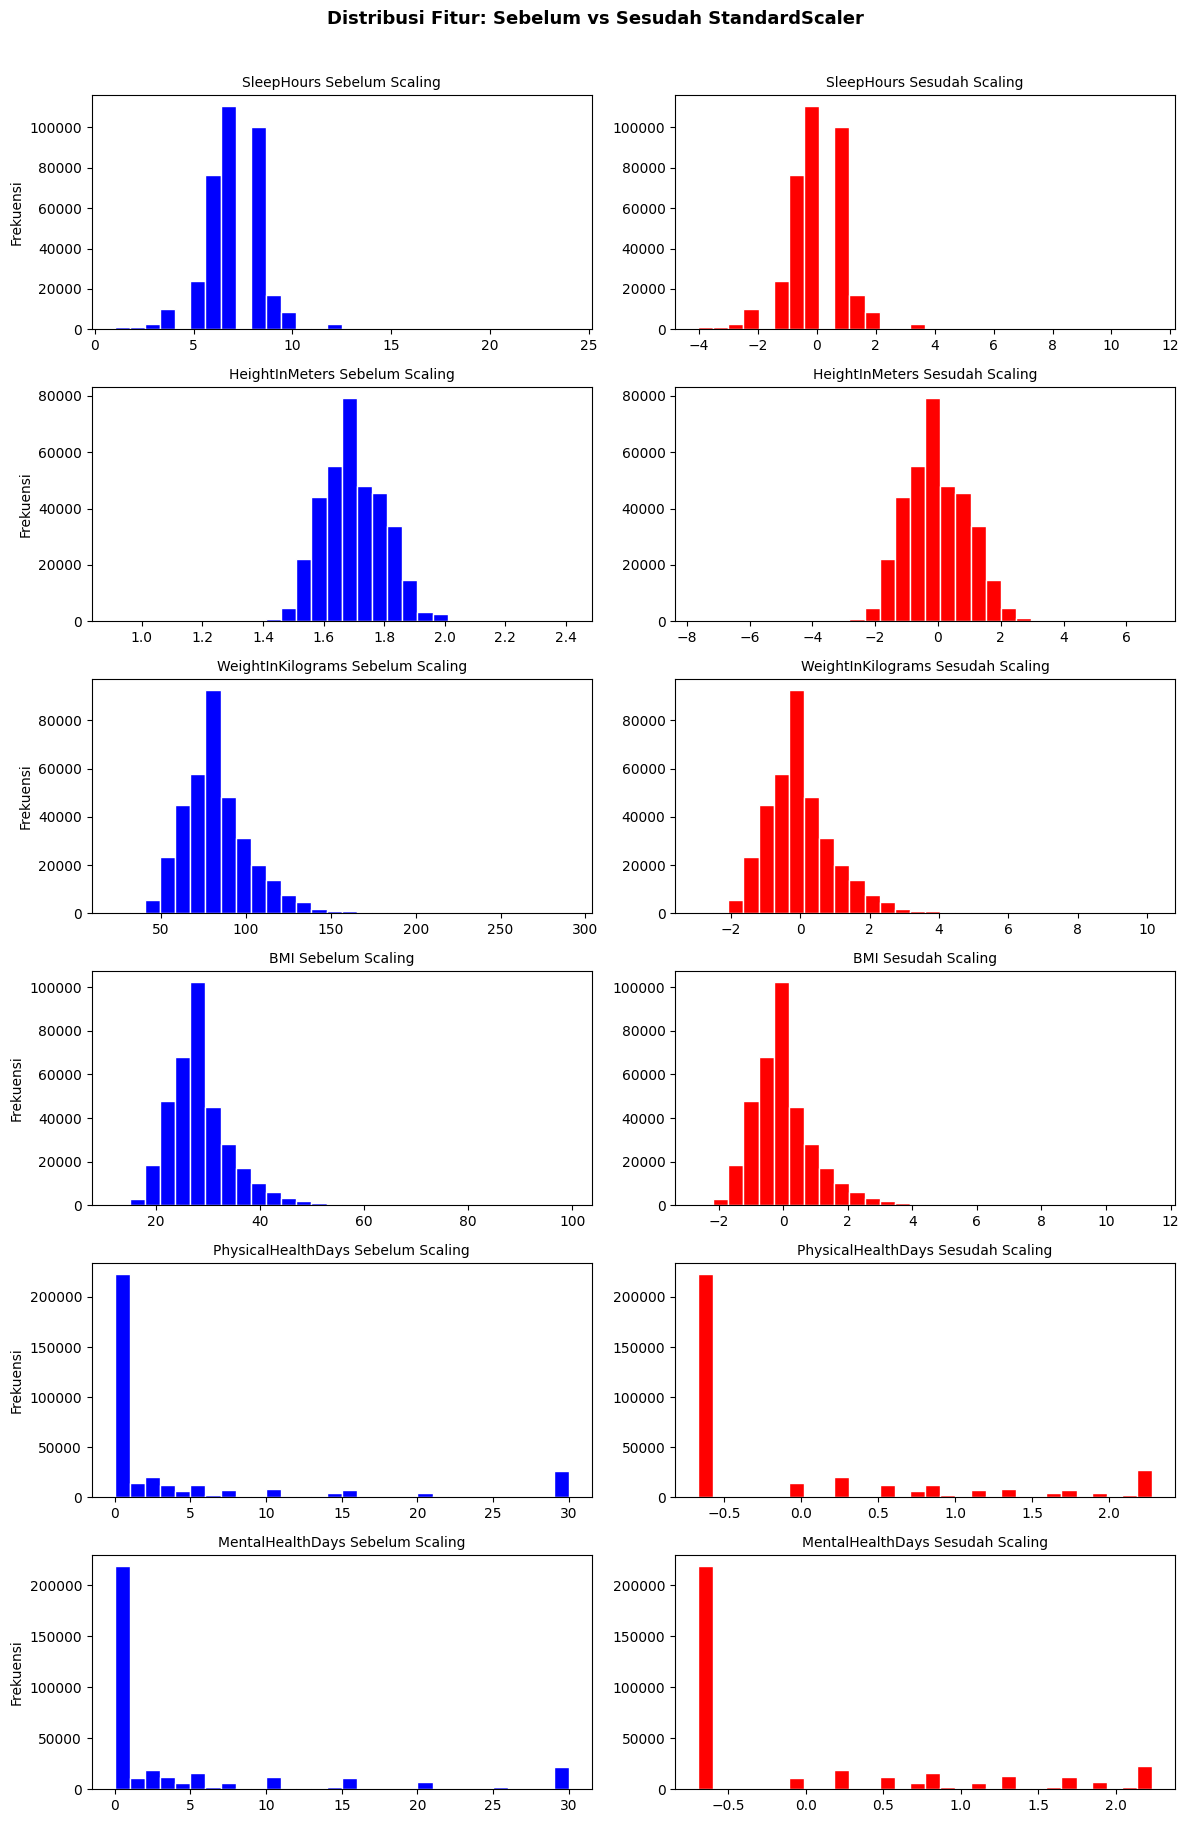

In [ ]:
fig, axes = plt.subplots(len(scale_cols), 2, figsize=(12, len(scale_cols) * 3))

for i, col in enumerate(scale_cols):
    axes[i, 0].hist(df_before[col], bins=30, color='blue', edgecolor='white')
    axes[i, 0].set_title(f'{col} Sebelum Scaling', fontsize=10)
    axes[i, 0].set_ylabel('Frekuensi')

    axes[i, 1].hist(X_train[col], bins=30, color='red', edgecolor='white')
    axes[i, 1].set_title(f'{col} Sesudah Scaling', fontsize=10)

plt.suptitle('Distribusi Fitur: Sebelum vs Sesudah StandardScaler',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Cek total NaN train
print("NaN X_train:", X_train.isnull().sum().sum())

# Kolom yang masih ada NaN
nan_cols = X_train.columns[X_train.isnull().any()]

print("\nKolom yang masih mengandung NaN:")
print(X_train[nan_cols].isnull().sum())

NaN X_train: 0

Kolom yang masih mengandung NaN:
Series([], dtype: float64)


# Baseline (Logistic Regresion)

In [ ]:
from sklearn.linear_model import LogisticRegression

Inisialisasi Model

In [ ]:
log_reg = LogisticRegression(
    max_iter=200,
    multi_class='multinomial',
    solver='saga',
    n_jobs=-1
)

Training Model

In [ ]:
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='multinomial', n_jobs=-1,
                   solver='saga')

Prediksi

In [ ]:
y_pred = log_reg.predict(X_test)

Evaluasi

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy Logistic Regression:", acc)

Accuracy Logistic Regression: 0.44322959522977556


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.30      0.38      3948
           1       0.44      0.30      0.36     12054
           2       0.43      0.48      0.45     28705
           3       0.45      0.65      0.53     29653
           4       0.41      0.10      0.17     14357

    accuracy                           0.44     88717
   macro avg       0.45      0.37      0.38     88717
weighted avg       0.44      0.44      0.42     88717



Confusion Matriks

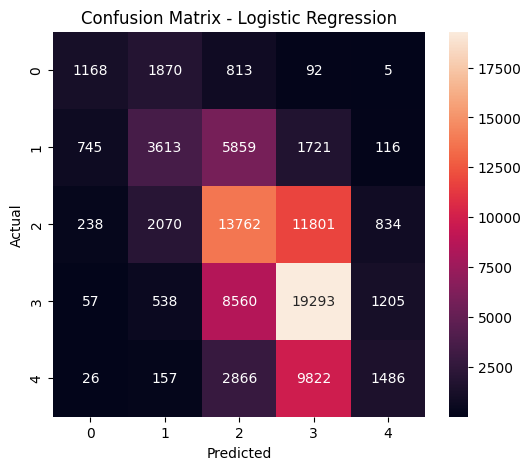

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

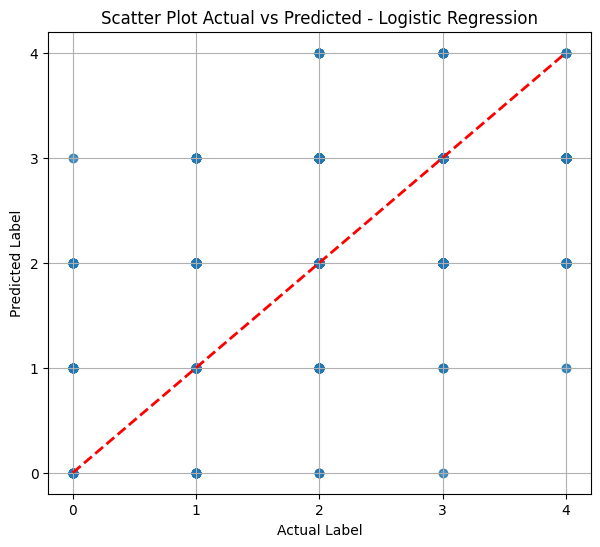

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Label")
plt.ylabel("Predicted Label")
plt.title("Scatter Plot Actual vs Predicted - Logistic Regression")

plt.xticks([0,1,2,3,4])
plt.yticks([0,1,2,3,4])

plt.grid(True)

plt.show()

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Inisialisasi Model

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

Training Model

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

Prediksi

In [ ]:
y_pred_rf = rf.predict(X_test)

Evaluasi

In [ ]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.44572066233078217


Classification Report

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.53      0.36      0.43      3948
           1       0.43      0.31      0.36     12054
           2       0.43      0.52      0.47     28705
           3       0.46      0.57      0.51     29653
           4       0.42      0.17      0.24     14357

    accuracy                           0.45     88717
   macro avg       0.45      0.39      0.40     88717
weighted avg       0.44      0.45      0.43     88717



Confusion Matrix

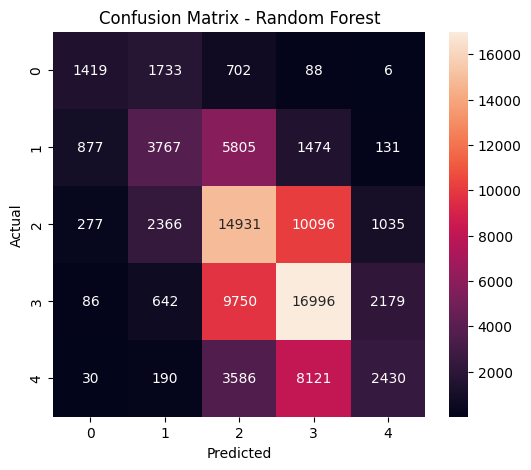

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Feature Importance

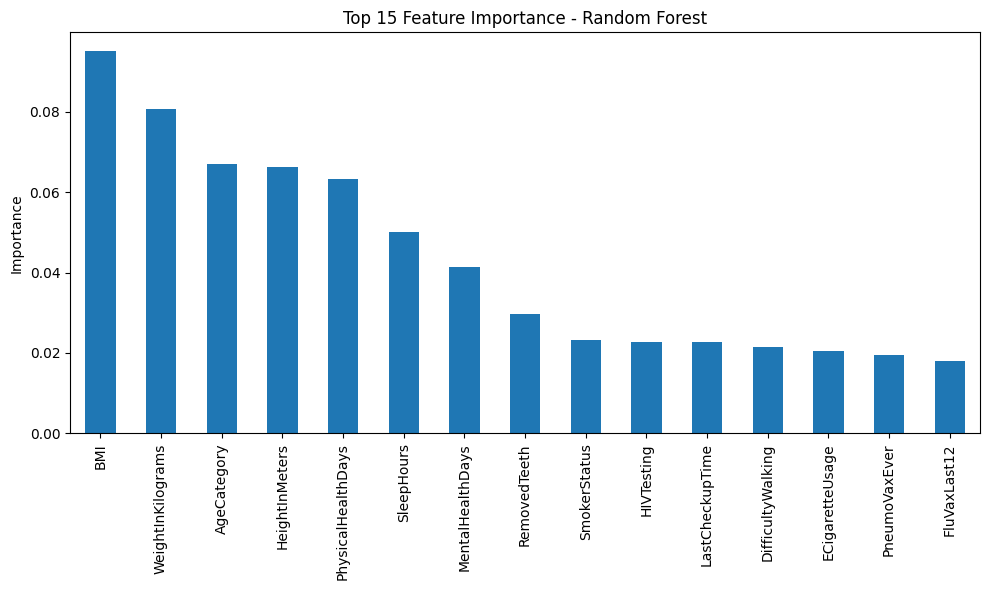

In [ ]:
importances = rf.feature_importances_
feat_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_importance[:15].plot(kind='bar')
plt.title("Top 15 Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Perbandingan dengan Baseline

In [ ]:
print(f"  Logistic Regression : {acc:.4f}")
print(f"  Random Forest       : {acc_rf:.4f}")

  Logistic Regression : 0.4432
  Random Forest       : 0.4457


# XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

inisaialisasi model

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)


training model

In [ ]:
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:02:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

prediksi

In [ ]:
y_pred_xgb = xgb.predict(X_test)

accuracy

In [ ]:
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("Accuracy XGBoost:", acc_xgb)

Accuracy XGBoost: 0.45766876697814396


classification report

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.52      0.41      0.46      3948
           1       0.45      0.31      0.36     12054
           2       0.44      0.51      0.47     28705
           3       0.47      0.62      0.53     29653
           4       0.46      0.16      0.24     14357

    accuracy                           0.46     88717
   macro avg       0.47      0.40      0.41     88717
weighted avg       0.46      0.46      0.44     88717



confusion matrix

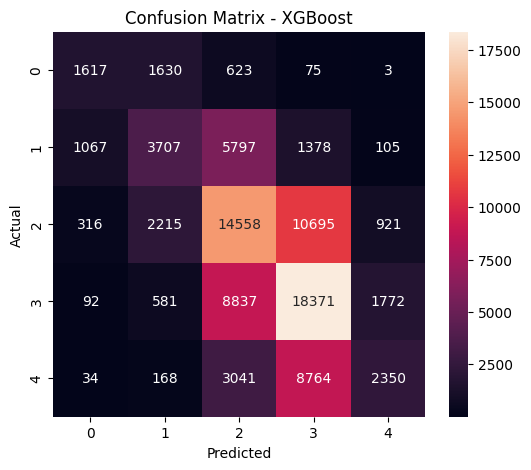

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


feature important

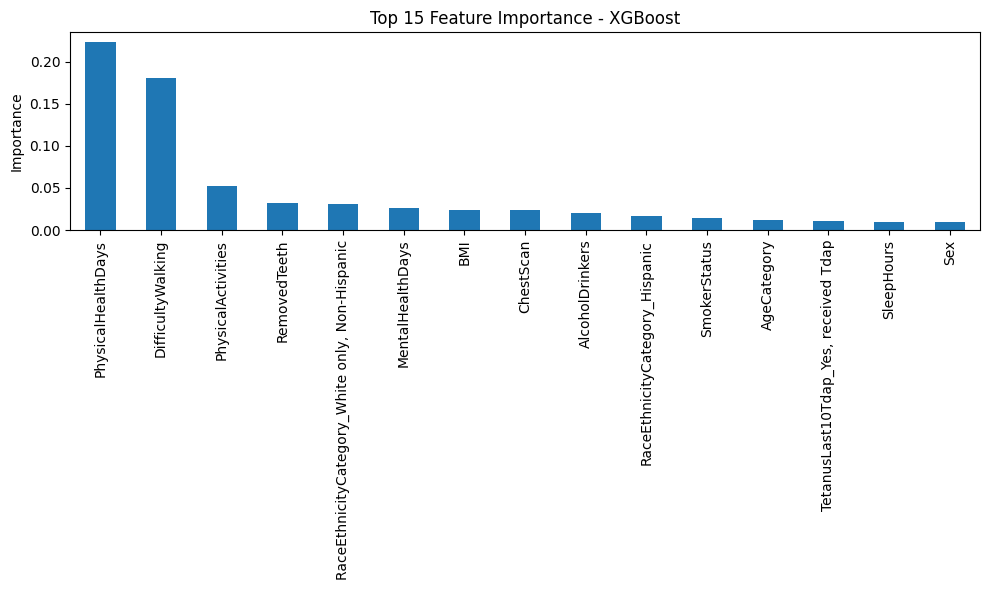

In [ ]:
importances_xgb = xgb.feature_importances_
feat_importance_xgb = pd.Series(importances_xgb, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importance_xgb[:15].plot(kind='bar')
plt.title("Top 15 Feature Importance - XGBoost")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# Perbandingan semua model

In [ ]:
print(f"  Logistic Regression : {acc:.4f}")
print(f"  Random Forest       : {acc_rf:.4f}")
print(f"  XGBoost             : {acc_xgb:.4f}")

  Logistic Regression : 0.4432
  Random Forest       : 0.4457
  XGBoost             : 0.4577
